In [2]:
import json
import re
import pandas as pd
from pathlib import Path
import ast

In [3]:
id_pattern = re.compile(r'ID\s+(\d+)')

with open("eval_prompts_same_first_global.json", "r") as f:
    eval_prompts = json.load(f)

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

out = {}

for itype, scenarios in eval_prompts.items():
    if itype == "json":
        continue

    for scenario, items in scenarios.items():
    
        out[scenario] = []

        for item in items:
            prompt = item['prompt']
            ids = id_pattern.findall(prompt)
            print(ids)
            out[scenario].append(ids)

['31926', '37989', '74418', '43375', '48780']
['18711', '51211', '51743', '55950', '57316']
['55086', '49556', '41277', '42272', '30721']
['6508', '39708', '26678', '46039', '14102']
['2425', '23132', '55305', '2277', '54372']
['75880', '59390', '28242', '67465', '80744']
['54232', '55950', '18711', '51743', '57316']
['10743', '60473', '63077', '53655', '57572']
['8257', '53579', '12043', '38478', '33084']
['17550', '8109', '53652', '3536', '79411']
['67584', '73827', '26052', '12104', '20502']
['17550', '10825', '23132', '53652', '3536']
['75880', '37989', '74418', '48780', '31926']
['31926', '74418', '48780', '1261', '37989']
['26703', '72517', '26372', '74633', '64729']
['59747', '55589', '33749', '47247', '26994']
['14102', '40550', '39708', '26678', '28732']
['53655', '10743', '60473', '63077', '7217']
['25607', '77045', '51393', '39708', '38835']
['73827', '3282', '4132', '64247', '62071']
['75880', '41154', '59474', '14834', '43375']
['53579', '38478', '11746', '12043', '64047']

In [4]:


with open('groups_same_first_global.json', 'r') as f:
    groups = json.load(f)

# with open('outputs/gemma/description__same_first.json', 'r') as f:
#     gemma_desc = json.load(f)

with open('outputs/human_description/llama/description__same_first_global.json', 'r') as f:
    llama_desc = json.load(f)

def extract_id(pred_str):
    nums = re.findall(r'\d+', pred_str)
    return nums[-1] if nums else None

for idx, entry in enumerate(groups):
    # entry['gemma_description_pick'] = extract_id(gemma_desc[idx]['predicted_id'])
    entry['llama_description_pick'] = extract_id(llama_desc[idx]['predicted_id'])

output_path = 'groups_same_first_global_results.json'
with open(output_path, 'w') as f:
    json.dump(groups, f, indent=2)

df = pd.DataFrame(groups)

df.to_csv("groups_same_first_global_results.csv", index=False)

In [28]:


with open('groups_diff_first.json', 'r') as f:
    groups = json.load(f)

with open('outputs/gemma/description__diff_first.json', 'r') as f:
    gemma_desc = json.load(f)

with open('outputs/llama/description__diff_first.json', 'r') as f:
    llama_desc = json.load(f)

def extract_id(pred_str):
    nums = re.findall(r'\d+', pred_str)
    return nums[-1] if nums else None

for idx, entry in enumerate(groups):
    entry['gemma_description_pick'] = extract_id(gemma_desc[idx]['predicted_id'])
    entry['llama_description_pick'] = extract_id(llama_desc[idx]['predicted_id'])

output_path = 'groups_diff_first_results.json'
with open(output_path, 'w') as f:
    json.dump(groups, f, indent=2)

df = pd.DataFrame(groups)

df.to_csv("groups_diff_first_results.csv", index=False)

In [57]:
# with open('groups_diff_first_results.json', 'r') as f:
#     data = json.load(f)

# df = pd.DataFrame(data)

df = pd.read_csv("groups_diff_first_results.csv")

gemma_correct = (df['gemma_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
llama_correct = (df['llama_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

gemma_accuracy = gemma_correct / total
llama_accuracy = llama_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print(f"Gemma Accuracy: {gemma_correct}/{total} = {gemma_accuracy:.2%}")
print(f"Llama Accuracy: {llama_correct}/{total} = {llama_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Gemma Accuracy: 24/100 = 24.00%
Llama Accuracy: 31/100 = 31.00%
op1 Accuracy: 18/100 = 18.00%
op2 Accuracy: 12/100 = 12.00%
op3 Accuracy: 19/100 = 19.00%
op4 Accuracy: 28/100 = 28.00%
Last Accuracy: 23/100 = 23.00%


In [58]:
# with open('groups_same_second_results.json', 'r') as f:
#     data = json.load(f)

# df = pd.DataFrame(data)

df = pd.read_csv("groups_same_second_results.csv")

gemma_correct = (df['gemma_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
llama_correct = (df['llama_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

gemma_accuracy = gemma_correct / total
llama_accuracy = llama_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print(f"Gemma Accuracy: {gemma_correct}/{total} = {gemma_accuracy:.2%}")
print(f"Llama Accuracy: {llama_correct}/{total} = {llama_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Gemma Accuracy: 26/100 = 26.00%
Llama Accuracy: 37/100 = 37.00%
op1 Accuracy: 16/100 = 16.00%
op2 Accuracy: 22/100 = 22.00%
op3 Accuracy: 14/100 = 14.00%
op4 Accuracy: 22/100 = 22.00%
Last Accuracy: 26/100 = 26.00%


In [59]:
df = pd.read_csv("groups_same_first_results.csv")

gemma_correct = (df['gemma_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
llama_correct = (df['llama_description_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

gemma_accuracy = gemma_correct / total
llama_accuracy = llama_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print(f"Gemma Accuracy: {gemma_correct}/{total} = {gemma_accuracy:.2%}")
print(f"Llama Accuracy: {llama_correct}/{total} = {llama_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Gemma Accuracy: 20/100 = 20.00%
Llama Accuracy: 19/100 = 19.00%
op1 Accuracy: 25/100 = 25.00%
op2 Accuracy: 19/100 = 19.00%
op3 Accuracy: 17/100 = 17.00%
op4 Accuracy: 20/100 = 20.00%
Last Accuracy: 19/100 = 19.00%


In [26]:
df = pd.read_csv("./outputs/image/original/groups_diff_first_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print("Outliers from any shape cluster\n")
print("original plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

df = pd.read_csv("./outputs/image/reoriented/groups_diff_first_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total
print("\n\nreoriented plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Outliers from any shape cluster

original plans: 
Qwen2.5 VL Accuracy: 29/100 = 29.00%
Phi4 Multimodal Accuracy: 34/100 = 34.00%
op1 Accuracy: 18/100 = 18.00%
op2 Accuracy: 12/100 = 12.00%
op3 Accuracy: 19/100 = 19.00%
op4 Accuracy: 28/100 = 28.00%
Last Accuracy: 23/100 = 23.00%


reoriented plans: 
Qwen2.5 VL Accuracy: 30/100 = 30.00%
Phi4 Multimodal Accuracy: 33/100 = 33.00%
op1 Accuracy: 18/100 = 18.00%
op2 Accuracy: 12/100 = 12.00%
op3 Accuracy: 19/100 = 19.00%
op4 Accuracy: 28/100 = 28.00%
Last Accuracy: 23/100 = 23.00%


In [27]:
df = pd.read_csv("./outputs/image/original/groups_same_second_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print("Outliers from the same shape cluster\n")
print("original plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

df = pd.read_csv("./outputs/image/reoriented/groups_same_second_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total
print("\n\nreoriented plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Outliers from the same shape cluster

original plans: 
Qwen2.5 VL Accuracy: 22/100 = 22.00%
Phi4 Multimodal Accuracy: 28/100 = 28.00%
op1 Accuracy: 16/100 = 16.00%
op2 Accuracy: 22/100 = 22.00%
op3 Accuracy: 14/100 = 14.00%
op4 Accuracy: 22/100 = 22.00%
Last Accuracy: 26/100 = 26.00%


reoriented plans: 
Qwen2.5 VL Accuracy: 33/100 = 33.00%
Phi4 Multimodal Accuracy: 27/100 = 27.00%
op1 Accuracy: 16/100 = 16.00%
op2 Accuracy: 22/100 = 22.00%
op3 Accuracy: 14/100 = 14.00%
op4 Accuracy: 22/100 = 22.00%
Last Accuracy: 26/100 = 26.00%


In [20]:
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

def add_legend_one_row(image: Image.Image, mapping: dict, gap: int = 10) -> Image.Image:
    swatch = 20
    pad    = 5
    font   = ImageFont.load_default()

    entries = list(mapping.items())
    tmp_draw = ImageDraw.Draw(image)
    
    # measure each label’s width via textbbox
    label_ws = []
    for _, label in entries:
        x0, y0, x1, y1 = tmp_draw.textbbox((0, 0), label, font=font)
        label_ws.append(x1 - x0)

    # compute total legend width & height
    total_w = sum(swatch + pad + w + pad for w in label_ws)
    leg_h   = swatch + 2*pad
    leg_w   = image.width

    # create legend canvas
    legend = Image.new("RGB", (leg_w, leg_h), "white")
    draw   = ImageDraw.Draw(legend)

    # horizontally center legend entries
    x_start = max((leg_w - total_w) // 2, pad)
    x = x_start
    for (color, label), w in zip(entries, label_ws):
        draw.rectangle([x, pad, x+swatch, pad+swatch], fill=color)
        draw.text((x+swatch+pad, pad), label, fill="black", font=font)
        x += swatch + pad + w + pad

    # stack image + gap + legend
    combined_h = image.height + gap + leg_h
    combined   = Image.new("RGB", (image.width, combined_h), "white")
    combined.paste(image, (0, 0))
    combined.paste(legend, (0, image.height + gap))

    return combined

In [21]:
COLOR_MAPPING = {
    (0xFF, 0xD7, 0x00): 'common room',
    (0xFF, 0xA5, 0x00): 'master room',
    (0xEE, 0xE8, 0xAA): 'living room',
    (0x6B, 0x8E, 0x23): 'balcony',
    (0xAD, 0xD8, 0xE6): 'bathroom',
    (0xF0, 0x80, 0x80): 'kitchen',
    (0xDD, 0xA0, 0xDD): 'storage',
    (0xDA, 0x70, 0xD6): 'dining',
}

In [29]:
data_dir = Path("./randomized_options/same_second_1-10")

out_dir  = data_dir.parent / "with_legend"
out_dir.mkdir(exist_ok=True)
images = []
for img_path in sorted(data_dir.glob("*.png")):
    img = Image.open(img_path).convert("RGB")
    img = add_legend_one_row(img, COLOR_MAPPING, gap=50)
    images.append(img)
    img.save(out_dir / img_path.name)
    print(f"Processed {img_path.name}")


Processed example_10_2.png
Processed example_1_2.png
Processed example_2_2.png
Processed example_3_2.png
Processed example_4_2.png
Processed example_5_2.png
Processed example_6_2.png
Processed example_7_2.png
Processed example_8_2.png
Processed example_9_2.png


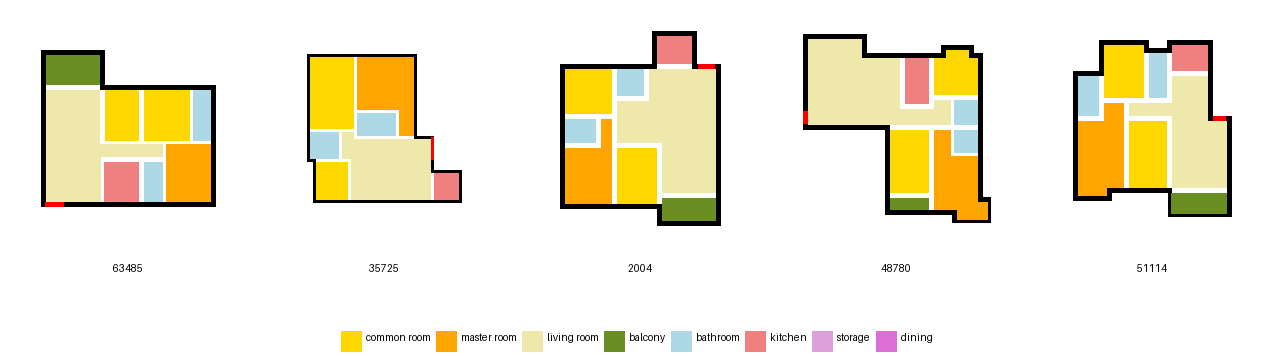

In [25]:
images[0]

In [5]:
df = pd.read_csv("./outputs/image/original_wlegend/groups_diff_first_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print("Outliers from any shape cluster\n")
print("original plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

df = pd.read_csv("./outputs/image/reoriented/groups_diff_first_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total
print("\n\nreoriented plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Outliers from any shape cluster

original plans: 
Qwen2.5 VL Accuracy: 33/100 = 33.00%
Phi4 Multimodal Accuracy: 32/100 = 32.00%
op1 Accuracy: 18/100 = 18.00%
op2 Accuracy: 12/100 = 12.00%
op3 Accuracy: 19/100 = 19.00%
op4 Accuracy: 28/100 = 28.00%
Last Accuracy: 23/100 = 23.00%


reoriented plans: 
Qwen2.5 VL Accuracy: 30/100 = 30.00%
Phi4 Multimodal Accuracy: 33/100 = 33.00%
op1 Accuracy: 18/100 = 18.00%
op2 Accuracy: 12/100 = 12.00%
op3 Accuracy: 19/100 = 19.00%
op4 Accuracy: 28/100 = 28.00%
Last Accuracy: 23/100 = 23.00%


In [4]:
df = pd.read_csv("./outputs/image/original_wlegend/groups_same_second_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total

print("Outliers from the same shape cluster\n")
print("original plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

df = pd.read_csv("./outputs/image/reoriented/groups_same_second_results.csv")

qwen_correct = (df['qwen_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
phi_correct = (df['phi_pick'].astype(int) == df['outlier_id'].astype(int)).sum()
op1_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[0]).astype(int) == df['outlier_id'].astype(int)).sum()
op2_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[1]).astype(int) == df['outlier_id'].astype(int)).sum()
op3_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[2]).astype(int) == df['outlier_id'].astype(int)).sum()
op4_correct = (df['options'].apply(lambda s: ast.literal_eval(s)[3]).astype(int) == df['outlier_id'].astype(int)).sum()
last_correct = (df['last_option'].astype(int) == df['outlier_id'].astype(int)).sum()
total = len(df)

qwen_accuracy = qwen_correct / total
phi_accuracy = phi_correct / total
op1_accuracy = op1_correct / total
op2_accuracy = op2_correct / total
op3_accuracy = op3_correct / total
op4_accuracy = op4_correct / total
last_accuracy = last_correct / total
print("\n\nreoriented plans: ")
print(f"Qwen2.5 VL Accuracy: {qwen_correct}/{total} = {qwen_accuracy:.2%}")
print(f"Phi4 Multimodal Accuracy: {phi_correct}/{total} = {phi_accuracy:.2%}")
print(f"op1 Accuracy: {op1_correct}/{total} = {op1_accuracy:.2%}")
print(f"op2 Accuracy: {op2_correct}/{total} = {op2_accuracy:.2%}")
print(f"op3 Accuracy: {op3_correct}/{total} = {op3_accuracy:.2%}")
print(f"op4 Accuracy: {op4_correct}/{total} = {op4_accuracy:.2%}")
print(f"Last Accuracy: {last_correct}/{total} = {last_accuracy:.2%}")

Outliers from the same shape cluster

original plans: 
Qwen2.5 VL Accuracy: 26/100 = 26.00%
Phi4 Multimodal Accuracy: 21/100 = 21.00%
op1 Accuracy: 16/100 = 16.00%
op2 Accuracy: 22/100 = 22.00%
op3 Accuracy: 14/100 = 14.00%
op4 Accuracy: 22/100 = 22.00%
Last Accuracy: 26/100 = 26.00%


reoriented plans: 
Qwen2.5 VL Accuracy: 33/100 = 33.00%
Phi4 Multimodal Accuracy: 27/100 = 27.00%
op1 Accuracy: 16/100 = 16.00%
op2 Accuracy: 22/100 = 22.00%
op3 Accuracy: 14/100 = 14.00%
op4 Accuracy: 22/100 = 22.00%
Last Accuracy: 26/100 = 26.00%
